# Robust PCA + Topology Benchmark

This notebook evaluates whether scalar persistent-homology features add incremental forecasting information beyond the active-set family-level PCA benchmark.

The benchmark is deliberately anti-overfit: chronological design folds, inner validation for configuration selection, one locked final holdout, placebo tests, H0/H1 ablations, and paired loss intervals.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == 'notebooks':
    PROJECT = PROJECT.parent
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from robust_pca_topology_benchmark import overall_summary, run_all

OUT = PROJECT / 'data' / 'processed'
RUN_FULL = False

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Run Or Reuse Saved Outputs

The full benchmark recomputes fold-specific scalar persistent-homology features and takes a while. By default this notebook loads the saved outputs. Set `RUN_FULL = True` to regenerate everything.

In [2]:
required = [
    OUT / 'robust_pca_topology_results.csv',
    OUT / 'robust_pca_topology_predictions.parquet',
    OUT / 'robust_pca_topology_calibration.csv',
    OUT / 'robust_pca_topology_ablation.csv',
    OUT / 'robust_pca_topology_placebo.csv',
    OUT / 'robust_pca_topology_summary.md',
]

if RUN_FULL or not all(path.exists() for path in required):
    predictions, results, calibration, placebo, ablation, summary_text = run_all(
        OUT / 'candidate_universe_markets.parquet',
        OUT / 'prices_long.parquet',
        OUT / 'universe_b_macro_crypto_panel.parquet',
        OUT,
    )
else:
    predictions = pd.read_parquet(OUT / 'robust_pca_topology_predictions.parquet')
    results = pd.read_csv(OUT / 'robust_pca_topology_results.csv')
    calibration = pd.read_csv(OUT / 'robust_pca_topology_calibration.csv')
    ablation = pd.read_csv(OUT / 'robust_pca_topology_ablation.csv')
    placebo = pd.read_csv(OUT / 'robust_pca_topology_placebo.csv')
    summary_text = (OUT / 'robust_pca_topology_summary.md').read_text()

print(summary_text)

ROBUST PCA + TOPOLOGY BENCHMARK SUMMARY

Dataset:
- markets: 171
- supervised rows: 532,979
- YES rate by unique market: 0.111
- timestamp range: 2024-08-06 17:00:00+00:00 to 2026-04-01 08:00:00+00:00

Locked holdout results:
- market probability: market_probability Brier 0.0464, log loss 0.1531, ECE 0.0224
- PCA-only: pca_only_fixed_5_C0.01 Brier 0.0467, log loss 0.1699, ECE 0.0114
- TDA-only: tda_only_168h_h0_h1_C0.01 Brier 0.0687, log loss 0.2432, ECE 0.0554
- PCA+TDA: pca_plus_tda_var_85_24h_h0_h1_C1 Brier 0.0467, log loss 0.1710, ECE 0.0191

Locked configs selected before holdout:
- PCA-only: pca_only_fixed_5_C0.01
- TDA-only: tda_only_168h_h0_h1_C0.01
- PCA+TDA: pca_plus_tda_var_85_24h_h0_h1_C1

Success criteria:
- Does PCA+TDA beat PCA-only on locked holdout Brier? no (+0.000030)
- Does PCA+TDA beat PCA-only on locked holdout log loss? no (+0.001179)
- Is the gain larger than 0.0005? no
- Is the gain consistent across design folds? no
- Does real TDA beat shuffled/future-shift p

## Locked Holdout Results

In [3]:
holdout = overall_summary(results, 'locked_holdout')
display(holdout[['representation', 'model', 'n_obs', 'brier', 'log_loss', 'ece', 'avg_pred', 'avg_actual']])

,representation,model,n_obs,brier,log_loss,ece,avg_pred,avg_actual
0,market_probability,market_probability,120760,0.046446,0.153142,0.022373,0.095690,0.101929
1,pca_only,pca_only_fixed_5_C0.01,120760,0.046692,0.169851,0.011428,0.101654,0.101929
2,pca_plus_tda,pca_plus_tda_var_85_24h_h0_h1_C1,120760,0.046721,0.171030,0.019062,0.094488,0.101929
3,tda_only,tda_only_168h_h0_h1_C0.01,120760,0.068696,0.243196,0.055358,0.143280,0.101929


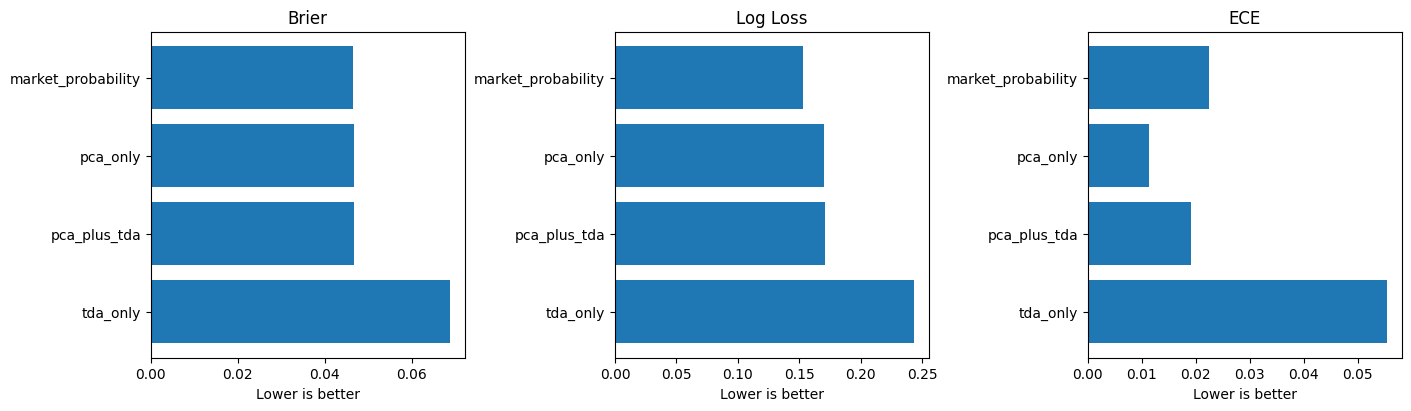

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
plot_df = holdout.sort_values('brier').copy()
for ax, metric, title in zip(axes, ['brier', 'log_loss', 'ece'], ['Brier', 'Log Loss', 'ECE']):
    ax.barh(plot_df['representation'], plot_df[metric])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Lower is better')
plt.show()

## Placebo And Ablation Checks

In [5]:
placebo_holdout = placebo[(placebo['split'] == 'locked_holdout') & (placebo['eval_group_type'] == 'overall')]
ablation_holdout = ablation[(ablation['split'] == 'locked_holdout') & (ablation['eval_group_type'] == 'overall')]
display(placebo_holdout[['placebo_type', 'model', 'n_obs', 'brier', 'log_loss', 'ece']])
display(ablation_holdout[['ablation_type', 'model', 'n_obs', 'brier', 'log_loss', 'ece']])

,placebo_type,model,n_obs,brier,log_loss,ece
198,shuffle,pca_plus_tda_var_85_24h_h0_h1_C1,120760,0.046752,0.171237,0.019474
206,future_shift,pca_plus_tda_var_85_24h_h0_h1_C1,120304,0.046694,0.170787,0.019477


,ablation_type,model,n_obs,brier,log_loss,ece
297,h0,pca_plus_tda_var_85_24h_h0_C1,120760,0.046719,0.171011,0.019126
305,h1,pca_plus_tda_var_85_24h_h1_C1,120760,0.046766,0.171342,0.019411
313,h0_h1,pca_plus_tda_var_85_24h_h0_h1_C1,120760,0.046721,0.171030,0.019062


## Calibration Snapshot

,split,fold,representation,model,prob_decile,n_obs,avg_pred,avg_actual
539,locked_holdout,999,market_probability,market_probability,0,96948,0.013894,0.019289
540,locked_holdout,999,market_probability,market_probability,1,5673,0.139293,0.224396
541,locked_holdout,999,market_probability,market_probability,2,3459,0.252678,0.115062
542,locked_holdout,999,market_probability,market_probability,3,3435,0.354871,0.275983
543,locked_holdout,999,market_probability,market_probability,4,4134,0.445571,0.441219
544,locked_holdout,999,market_probability,market_probability,5,1278,0.545489,0.381847
545,locked_holdout,999,market_probability,market_probability,6,1177,0.642471,0.941376
546,locked_holdout,999,market_probability,market_probability,7,1392,0.745532,0.839080
547,locked_holdout,999,market_probability,market_probability,8,1243,0.859091,0.974256
548,locked_holdout,999,market_probability,market_probability,9,2021,0.952148,1.000000


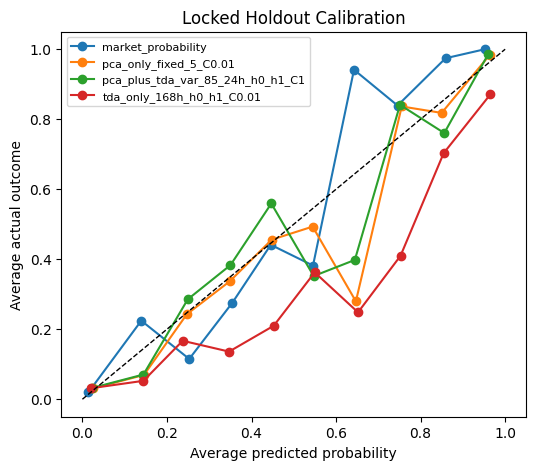

In [6]:
cal = calibration[calibration['split'].eq('locked_holdout')].copy()
display(cal.head(20))

fig, ax = plt.subplots(figsize=(6, 5))
for model, group in cal.groupby('model'):
    by_decile = group.groupby('prob_decile', as_index=False).agg(avg_pred=('avg_pred', 'mean'), avg_actual=('avg_actual', 'mean'))
    ax.plot(by_decile['avg_pred'], by_decile['avg_actual'], marker='o', label=model)
ax.plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Average predicted probability')
ax.set_ylabel('Average actual outcome')
ax.set_title('Locked Holdout Calibration')
ax.legend(fontsize=8)
plt.show()